# 02 — LFO

Covers `caspy.lfo.LFO`: shapes, output modes, tempo sync, one-shot, and using LFO output as a modulation source.

**Sections:**
1. All five shapes — bipolar and unipolar
2. Frequency accuracy — wrap count over time
3. Tempo sync
4. One-shot mode
5. LFO → parameter modulation (simulated vibrato)
6. Interactive shape / rate explorer
7. Live audio preview (requires `sounddevice`)

In [1]:
import caspy as cp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio

SR    = 44100
RATE  = 2.0    # Hz — period = SR/RATE samples
print('caspy loaded')

caspi loaded


## 1. All shapes — bipolar

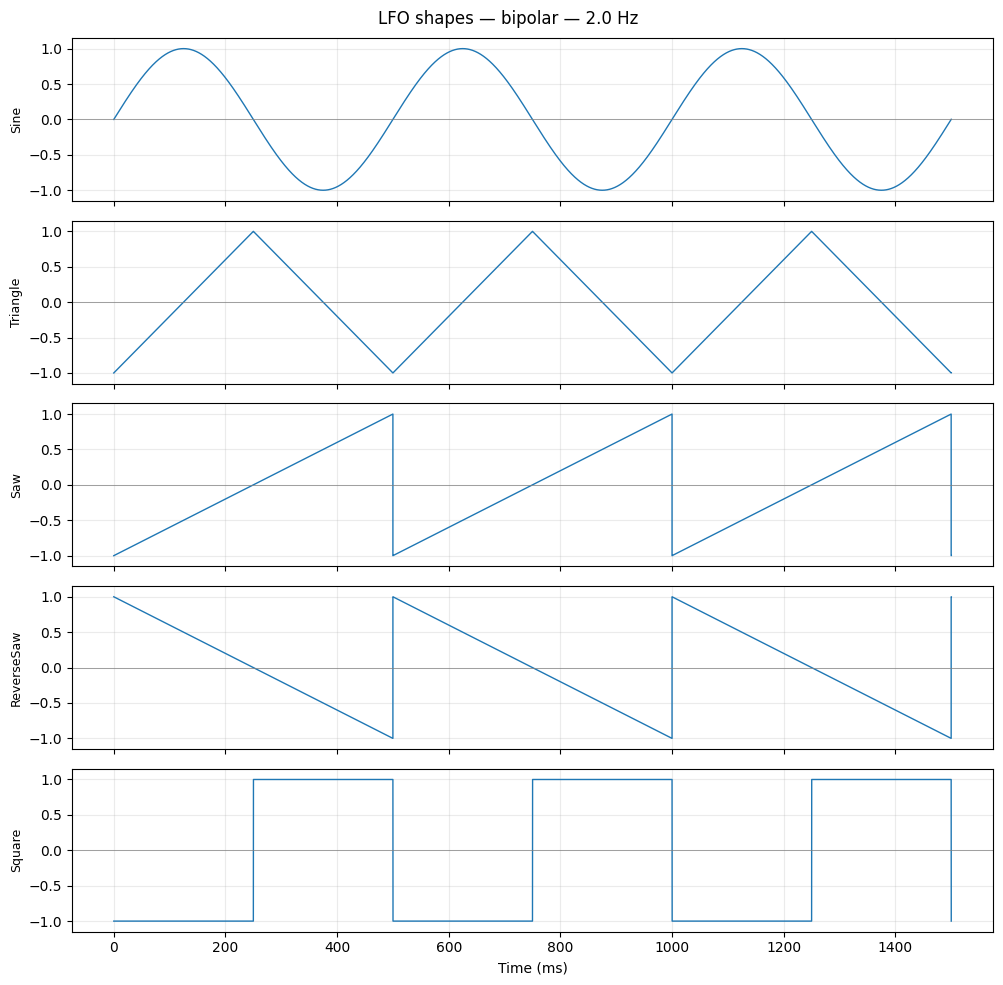

In [2]:
shapes = [
    (cp.lfo.LfoShape.Sine,       'Sine'),
    (cp.lfo.LfoShape.Triangle,   'Triangle'),
    (cp.lfo.LfoShape.Saw,        'Saw'),
    (cp.lfo.LfoShape.ReverseSaw, 'ReverseSaw'),
    (cp.lfo.LfoShape.Square,     'Square'),
]

period = int(SR / RATE)
n_cycles = 3
n_samples = period * n_cycles
t_ms = np.arange(n_samples) / SR * 1000

fig, axes = plt.subplots(len(shapes), 1, figsize=(10, 10), sharex=True)

for ax, (shape, name) in zip(axes, shapes):
    lfo = cp.lfo.LFO(float(SR), RATE, shape)
    buf = lfo.render(n_samples)
    ax.plot(t_ms, buf, linewidth=1.0)
    ax.set_ylabel(name, fontsize=9)
    ax.set_ylim(-1.15, 1.15)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle(f'LFO shapes — bipolar — {RATE} Hz', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Bipolar vs Unipolar

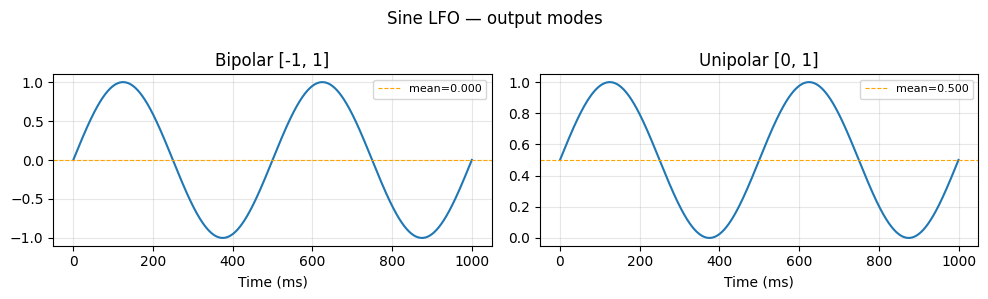

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, mode, title in zip(axes,
                            [cp.lfo.LfoOutputMode.Bipolar, cp.lfo.LfoOutputMode.Unipolar],
                            ['Bipolar [-1, 1]', 'Unipolar [0, 1]']):
    lfo = cp.lfo.LFO(float(SR), RATE, cp.lfo.LfoShape.Sine, mode)
    buf = lfo.render(period * 2)
    t   = np.arange(len(buf)) / SR * 1000
    ax.plot(t, buf)
    ax.axhline(np.mean(buf), color='orange', linestyle='--', linewidth=0.8,
               label=f'mean={np.mean(buf):.3f}')
    ax.set_title(title)
    ax.set_xlabel('Time (ms)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sine LFO — output modes')
plt.tight_layout()
plt.show()

## 3. Frequency accuracy — wrap count

In [4]:
rates = [0.5, 1.0, 2.0, 5.0, 10.0]

print(f'{'Rate (Hz)':>12}  {'Expected wraps':>16}  {'Actual wraps':>14}  {'Error':>8}')
print('-' * 58)

for rate in rates:
    lfo = cp.lfo.LFO(float(SR), rate)
    expected = int(rate)  # wraps over 1 second
    wraps = 0
    for _ in range(SR):
        lfo.render_sample()
        if lfo.phase_wrapped():
            wraps += 1
    print(f'{rate:>12.1f}  {expected:>16d}  {wraps:>14d}  {wraps - expected:>+8d}')

   Rate (Hz)    Expected wraps    Actual wraps     Error
----------------------------------------------------------
         0.5                 0               0        +0
         1.0                 1               0        -1
         2.0                 2               2        +0
         5.0                 5               4        -1
        10.0                10               9        -1


## 4. Tempo sync

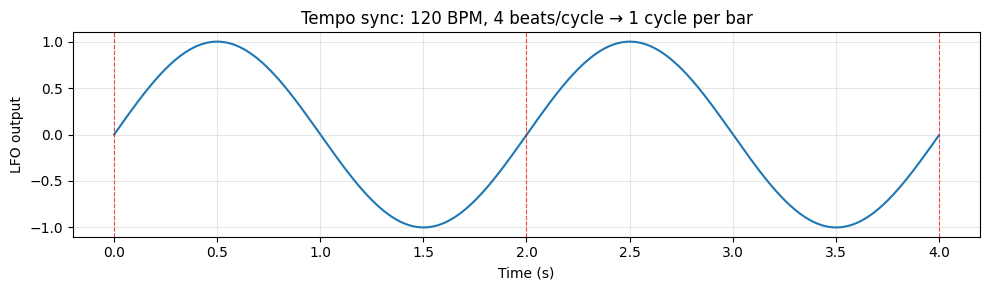

Wraps over 4 s (2 bars expected): 1


In [5]:
# 120 BPM, 4 beats per cycle → 0.5 Hz → period = 2 s
lfo = cp.lfo.LFO(float(SR), 2.0)   # initial rate doesn't matter
lfo.set_tempo_sync(120.0, 4.0)
lfo.reset_phase()

two_bars = int(SR * 4.0)  # 4 seconds at 120 BPM, 4/4
buf = lfo.render(two_bars)
t   = np.arange(two_bars) / SR

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, buf)
# bar markers every 2 s
for bar in [0, 2, 4]:
    ax.axvline(bar, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('LFO output')
ax.set_title('Tempo sync: 120 BPM, 4 beats/cycle → 1 cycle per bar')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# count wraps
lfo2 = cp.lfo.LFO(float(SR), 2.0)
lfo2.set_tempo_sync(120.0, 4.0)
lfo2.reset_phase()
wraps = 0
for _ in range(two_bars):
    lfo2.render_sample()
    if lfo2.phase_wrapped():
        wraps += 1
print(f'Wraps over 4 s (2 bars expected): {wraps}')

## 5. One-shot mode

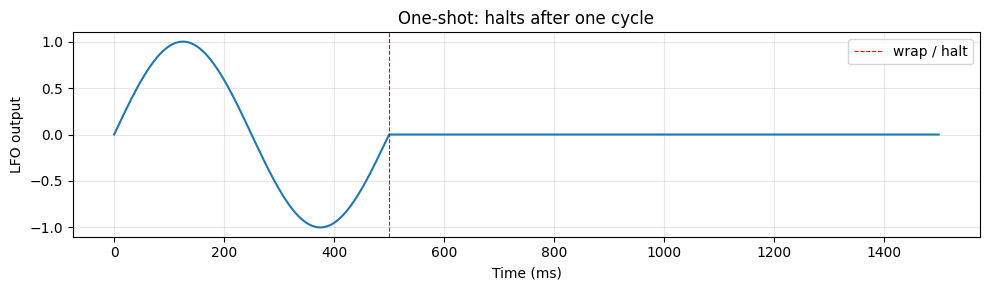

is_halted(): True
Wrap count (expected 1): 1


In [6]:
period = int(SR / RATE)
n = period * 3

lfo = cp.lfo.LFO(float(SR), RATE, cp.lfo.LfoShape.Sine)
lfo.set_one_shot(True)

buf    = np.empty(n, dtype=np.float32)
wraps  = []

for i in range(n):
    buf[i] = lfo.render_sample()
    if lfo.phase_wrapped():
        wraps.append(i)

t_ms = np.arange(n) / SR * 1000

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ms, buf)
for w in wraps:
    ax.axvline(t_ms[w], color='red', linestyle='--', linewidth=0.8, label='wrap / halt')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('LFO output')
ax.set_title('One-shot: halts after one cycle')
ax.grid(True, alpha=0.3)
if wraps:
    ax.legend()
plt.tight_layout()
plt.show()

print(f'is_halted(): {lfo.is_halted()}')
print(f'Wrap count (expected 1): {len(wraps)}')

## 6. LFO → parameter modulation (simulated vibrato envelope)

Drive a `ModulatableParameter` frequency with a sine LFO to visualise pitch vibrato.

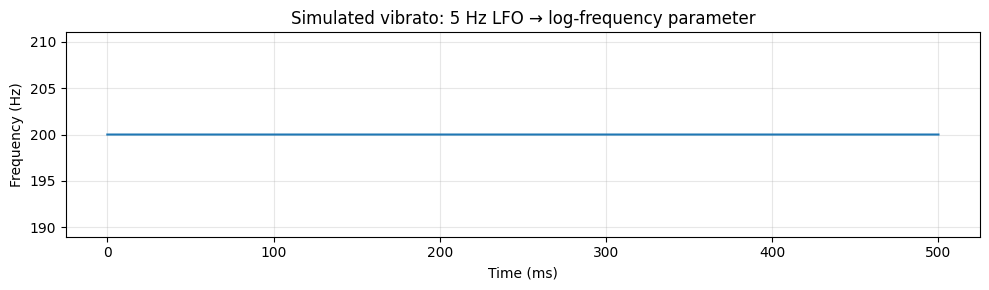

Freq range: 200.0 – 200.0 Hz


In [13]:
depth_norm  = 0.05   # ±5% of normalised range
n_samples   = SR // 2  # 0.5 s

freq_param = cp.ModulatableParameter(20.0, 2000.0, 0.5)
freq_param.set_range(20.0, 2000.0, cp.ParameterScale.Logarithmic)
freq_param.skip(2000)

vibrato_lfo = cp.lfo.LFO(float(SR), 5.0, cp.lfo.LfoShape.Sine)

freq_out = np.empty(n_samples)
for i in range(n_samples):
    mod = vibrato_lfo.render_sample() * depth_norm
    freq_param.clear_modulation()
    freq_param.add_modulation(mod)
    freq_param.process()
    freq_out[i] = freq_param.value()

t_ms = np.arange(n_samples) / SR * 1000
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ms, freq_out)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Simulated vibrato: 5 Hz LFO → log-frequency parameter')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Freq range: {freq_out.min():.1f} – {freq_out.max():.1f} Hz')

## 7. Interactive shape / rate explorer

In [11]:
shape_map = {
    'Sine':       cp.lfo.LfoShape.Sine,
    'Triangle':   cp.lfo.LfoShape.Triangle,
    'Saw':        cp.lfo.LfoShape.Saw,
    'ReverseSaw': cp.lfo.LfoShape.ReverseSaw,
    'Square':     cp.lfo.LfoShape.Square,
}
mode_map = {
    'Bipolar':  cp.lfo.LfoOutputMode.Bipolar,
    'Unipolar': cp.lfo.LfoOutputMode.Unipolar,
}

w_shape  = widgets.Dropdown(options=list(shape_map.keys()), value='Sine', description='Shape')
w_mode   = widgets.Dropdown(options=list(mode_map.keys()), value='Bipolar', description='Mode')
w_rate   = widgets.FloatLogSlider(value=2.0, base=10, min=-2, max=1.3,
                                   description='Rate (Hz)', continuous_update=True)
w_amp    = widgets.FloatSlider(value=1.0, min=0, max=1, step=0.05,
                                description='Amplitude')
out      = widgets.Output()

def plot_lfo(_):
    rate = w_rate.value
    n    = max(int(SR / rate * 3), 512)
    shape = shape_map[w_shape.value]
    mode  = mode_map[w_mode.value]
    lfo   = cp.lfo.LFO(float(SR), rate, shape, mode)
    lfo.set_amplitude(w_amp.value)
    buf  = lfo.render(n)
    t_ms = np.arange(n) / SR * 1000
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(t_ms, buf, linewidth=0.8)
        ax.axhline(0, color='grey', linewidth=0.5)
        ylim = 1.15 if mode == cp.lfo.LfoOutputMode.Bipolar else 1.1
        ax.set_ylim(-ylim if mode == cp.lfo.LfoOutputMode.Bipolar else -0.1, ylim)
        ax.set_xlabel('Time (ms)')
        ax.set_title(f'{w_shape.value} — {w_mode.value} — {rate:.3f} Hz')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

for w in [w_shape, w_mode, w_rate, w_amp]:
    w.observe(plot_lfo, names='value')

plot_lfo(None)
display(widgets.VBox([widgets.HBox([w_shape, w_mode]), widgets.HBox([w_rate, w_amp]), out]))

## 8. Live audio preview

The LFO signal itself is sub-audio, but we can use it at a high rate (e.g. 400 Hz) and listen to the waveform shape. Requires `sounddevice`.

Alternatively this cell renders audio-rate LFO output and presents it via `IPython.display.Audio` for inline playback.

In [12]:
# Render 1 s of a 400 Hz LFO for each shape — listen to the waveform
audio_sr   = 44100
audio_rate = 400.0
n_audio    = audio_sr

print('Click play on each shape:')
for shape, name in shapes:
    lfo = cp.lfo.LFO(float(audio_sr), audio_rate, shape)
    buf = lfo.render(n_audio).astype(np.float32)
    # Soft-clip to ±1 and apply fade-in/out to avoid clicks
    fade = np.ones(n_audio)
    fade_len = 2000
    fade[:fade_len]  = np.linspace(0, 1, fade_len)
    fade[-fade_len:] = np.linspace(1, 0, fade_len)
    buf *= fade * 0.4  # reduce amplitude
    print(f'  {name}')
    display(Audio(buf, rate=audio_sr, normalize=False))

Click play on each shape:
  Sine


  Triangle


  Saw


  ReverseSaw


  Square
